# Analyse surface elevation changes (dh/dt)

## CryoSat's CryoTEMPO data

- Dataset: **ESA CryoSat-2, L3, CryoTEMPO, EOLIS Gridded Product, Baseline 2**
    - 2km resolution data set of surface elevation over time
    - We download two data sets, representing one time slice each. We process **2011-01** (earliest January available) and **2025-01** (latest January available) and calculate the change over time.
    - This (gridded) data is only available for the margins (shelves), not the deep interior. However it includes parts of Byrd glacier, overlapping/adjacent to our three selected regions. This gives us a good enough impression of surface elevation changes, i.e. thinning. 
    - References: 
        - “EOLIS elevation data generated using swath processing of CryoSat-2 data (Jakob & Gourmelen, 2023) and provided by the ESA CryoTEMPO project (https://cryotempo-eolis.org/).”
        - Data over ice sheets – “EOLIS elevation data generated using swath processing of CryoSat-2 data (Gourmelen et al., 2018) and provided by the ESA CryoTEMPO project (https://cryotempo-eolis.org/).”

# Results on analysis

According to the CryoSat data the Byrd region of interest has had an average yearly elevation change of -0.016 meters / year, which is < 2 cm / year, over the past 14 years.

In [1]:
# use dfngp_env
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [6]:
# Replace with your own data path
eolis_2011_01 = xr.open_dataset("/home/kim/ice_thickness/data/eolis/CS_OFFL_THEM_GRID__ANTARCTIC_2011_01_V201.nc")
eolis_2025_01 = xr.open_dataset("/home/kim/ice_thickness/data/eolis/CS_OFFL_THEM_GRID__ANTARCTIC_2025_01_V201.nc")

## Visualise extent of data

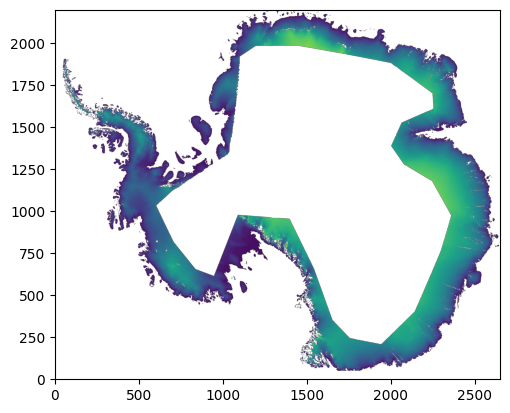

In [ ]:
eolis_2011_01.elevation.values

# NOTE: Have to transpose and origin lower (because it is (x, y) order)
plt.imshow(eolis_2011_01.elevation.values.squeeze().T, cmap = 'viridis', origin = 'lower')

## Subset Byrd region and visualise

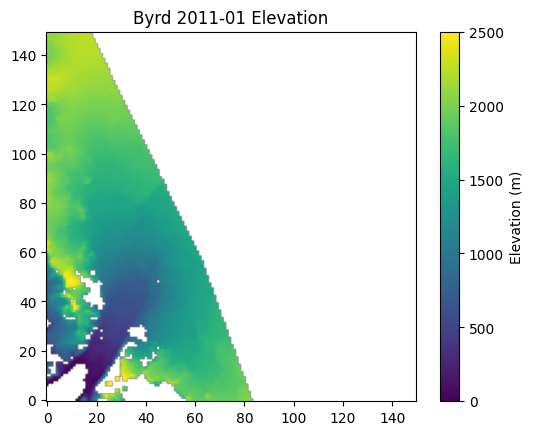

In [20]:
byrd_2011_01 = eolis_2011_01.sel(
    x = slice(350_000, 650_000),
    y = slice(-1_000_000, -700_000) # both are increasing
)

byrd_2025_01 = eolis_2025_01.sel(
    x = slice(350_000, 650_000),
    y = slice(-1_000_000, -700_000) # both are increasing
)

# h = height 
byrd_h_2011_01 = byrd_2011_01.elevation.values.squeeze().T
byrd_h_2025_01 = byrd_2025_01.elevation.values.squeeze().T

plt.imshow(byrd_h_2011_01, cmap = 'viridis', origin = 'lower', vmin = 0, vmax = 2500)
plt.title("Byrd 2011-01 Elevation")
plt.colorbar(label = "Elevation (m)")  # Optional
plt.show()

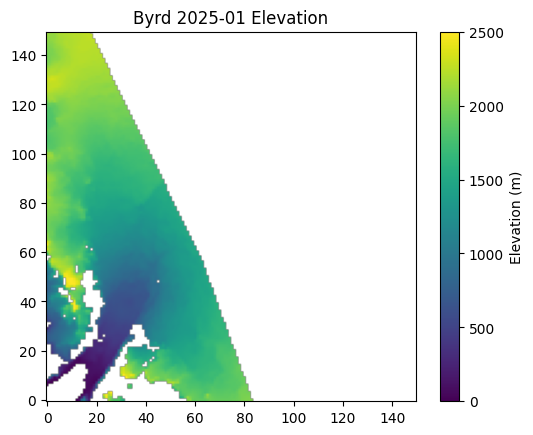

In [21]:
plt.imshow(byrd_h_2025_01, cmap = 'viridis', origin = 'lower', vmin = 0, vmax = 2500)
plt.title("Byrd 2025-01 Elevation")
plt.colorbar(label = "Elevation (m)")  # Optional
plt.show()

# Zoom into lower, mid, and upper Byrd

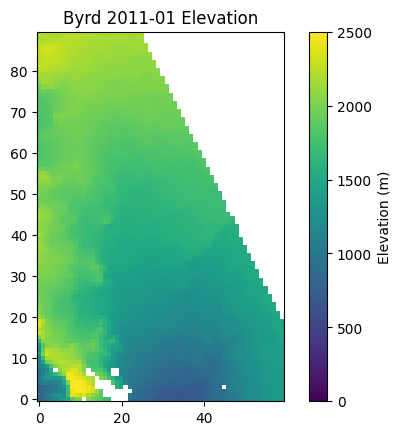

In [39]:
byrd_lower_mid_upper_2011_01 = eolis_2011_01.sel(
    x = slice(350_000, 470_000),
    y = slice(-910_000, -730_000)
)

byrd_lower_mid_upper_2025_01 = eolis_2025_01.sel(
    x = slice(350_000, 470_000),
    y = slice(-910_000, -730_000)
)

# h = height 
byrd_lmu_2011_01 = byrd_lower_mid_upper_2011_01.elevation.values.squeeze().T
byrd_lmu_2025_01 = byrd_lower_mid_upper_2025_01.elevation.values.squeeze().T

plt.imshow(byrd_lmu_2011_01, cmap = 'viridis', origin = 'lower', vmin = 0, vmax = 2500)
plt.title("Byrd 2011-01 Elevation")
plt.colorbar(label = "Elevation (m)")
plt.show()

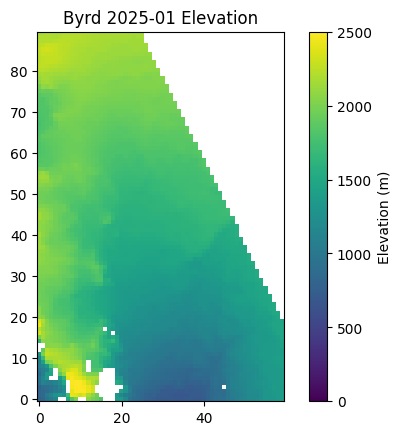

In [40]:
plt.imshow(byrd_lmu_2025_01, cmap = 'viridis', origin = 'lower', vmin = 0, vmax = 2500)
plt.title("Byrd 2025-01 Elevation")
plt.colorbar(label = "Elevation (m)")
plt.show()

# Calculate elevation change dh/dt

where h is height and t is time.

In [45]:
dhdt = byrd_lmu_2025_01 - byrd_lmu_2011_01
t_in_years = 2025 - 2011

print(f"Highest elevation change (in [m]): {np.nanmax(dhdt).item():.3f}")
print(f"Lowest elevation change (in [m]): {np.nanmin(dhdt).item():.3f}")

# Mean across the domain
mean_dhdt = np.nanmean(dhdt).item()
mean_absolute_dhdt = np.nanmean(np.abs(dhdt)).item()
print(f"Mean elevation change (in [m]): {mean_dhdt:.3f}")
print(f"Mean elevation change per year (in [m/year]): {mean_dhdt / t_in_years:.3f}")
print("in cm/year:")
print(f"Mean elevation change per year (in [cm/year]): {mean_dhdt / t_in_years * 100:.3f}")

Highest elevation change (in [m]): 5.517
Lowest elevation change (in [m]): -4.212
Mean elevation change (in [m]): -0.219
Mean elevation change per year (in [m/year]): -0.016
in cm/year:
Mean elevation change per year (in [cm/year]): -1.567
